In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from useful_func import missing_info,out_info

In [ ]:
df = pd.read_csv('/content/h1n1_vaccine_prediction.csv')
df.head()

,unique_id,h1n1_worry,h1n1_awareness,antiviral_medication,contact_avoidance,bought_face_mask,wash_hands_frequently,avoid_large_gatherings,reduced_outside_home_cont,avoid_touch_face,...,race,sex,income_level,marital_status,housing_status,employment,census_msa,no_of_adults,no_of_children,h1n1_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,Non-MSA,0.0,0.0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,White,Male,Below Poverty,Not Married,Rent,Employed,"MSA, Not Principle City",0.0,0.0,0
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,"MSA, Not Principle City",2.0,0.0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Principle City",0.0,0.0,0
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,0.0,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Find missing values
missing_info(df)

,column_name,num_missing,missing%
0,has_health_insur,12274,45.96
1,income_level,4423,16.56
2,dr_recc_h1n1_vacc,2160,8.09
3,dr_recc_seasonal_vacc,2160,8.09
4,housing_status,2042,7.65
5,employment,1463,5.48
6,marital_status,1408,5.27
7,qualification,1407,5.27
8,chronic_medic_condition,971,3.64
9,cont_child_undr_6_mnths,820,3.07


In [ ]:
# Find number of poeple that has heath insu. taking vaccine
# VS not taking vaccine
df["has_health_insur"].value_counts(dropna = False)

,count
has_health_insur,
1.0,12697
NaN,12274
0.0,1736


In [ ]:
df.columns

Index(['unique_id', 'h1n1_worry', 'h1n1_awareness', 'antiviral_medication',
       'contact_avoidance', 'bought_face_mask', 'wash_hands_frequently',
       'avoid_large_gatherings', 'reduced_outside_home_cont',
       'avoid_touch_face', 'dr_recc_h1n1_vacc', 'dr_recc_seasonal_vacc',
       'chronic_medic_condition', 'cont_child_undr_6_mnths',
       'is_health_worker', 'has_health_insur', 'is_h1n1_vacc_effective',
       'is_h1n1_risky', 'sick_from_h1n1_vacc', 'is_seas_vacc_effective',
       'is_seas_risky', 'sick_from_seas_vacc', 'age_bracket', 'qualification',
       'race', 'sex', 'income_level', 'marital_status', 'housing_status',
       'employment', 'census_msa', 'no_of_adults', 'no_of_children',
       'h1n1_vaccine'],
      dtype='object')

In [ ]:
temp_df = df[["has_health_insur", "h1n1_vaccine"]].fillna("missing").copy()
temp_df

,has_health_insur,h1n1_vaccine
0,1.0,0
1,1.0,0
2,missing,0
3,missing,0
4,missing,0
...,...,...
26702,missing,0
26703,1.0,0
26704,missing,0
26705,0.0,0


In [ ]:
temp1 = temp_df.groupby(by = ["has_health_insur", "h1n1_vaccine"],
                as_index= False)["h1n1_vaccine"].size()

temp2 =  temp_df["has_health_insur"].value_counts().reset_index()
temp3 = pd.merge(left = temp1 , right = temp2, on = "has_health_insur" , how = "inner")
temp3["per"] = temp3["size"]/temp3["count"] * 100
temp3

,has_health_insur,h1n1_vaccine,size,count,per
0,0.0,0,1480,1736,85.253456
1,0.0,1,256,1736,14.746544
2,1.0,0,8663,12697,68.228715
3,1.0,1,4034,12697,31.771285
4,missing,0,10890,12274,88.724132
5,missing,1,1384,12274,11.275868


In [ ]:
temp4 = pd.crosstab(temp_df["h1n1_vaccine"],temp_df["has_health_insur"])
total = temp4.values.sum(axis=0)
temp4/total

has_health_insur,0.0,1.0,missing
h1n1_vaccine,,,
0,0.852535,0.682287,0.887241
1,0.147465,0.317713,0.112759


In [ ]:
a = pd.crosstab(temp_df["h1n1_vaccine"],temp_df["has_health_insur"]).values
a/a.sum(axis = 0)

array([[0.85253456, 0.68228715, 0.88724132],
       [0.14746544, 0.31771285, 0.11275868]])

In [ ]:
df["income_level"].value_counts(dropna = False)

,count
income_level,
"<= $75,000, Above Poverty",12777
"> $75,000",6810
NaN,4423
Below Poverty,2697


In [ ]:
temp4 = pd.crosstab(temp_df["h1n1_vaccine"],df["income_level"].fillna("missing"))
total = temp4.values.sum(axis=0)
temp4/total

income_level,"<= $75,000, Above Poverty","> $75,000",Below Poverty,missing
h1n1_vaccine,,,,
0,0.796588,0.74699,0.808676,0.810988
1,0.203412,0.25301,0.191324,0.189012


In [ ]:
temp_df = missing_info(df)
temp_df

,column_name,num_missing,missing%
0,has_health_insur,12274,45.96
1,income_level,4423,16.56
2,dr_recc_h1n1_vacc,2160,8.09
3,dr_recc_seasonal_vacc,2160,8.09
4,housing_status,2042,7.65
5,employment,1463,5.48
6,marital_status,1408,5.27
7,qualification,1407,5.27
8,chronic_medic_condition,971,3.64
9,cont_child_undr_6_mnths,820,3.07


In [ ]:
moderate_missing_cols = temp_df.loc[2:7, "column_name"]
low_missing_cols = temp_df.loc[8:13, "column_name"]
very_low_missing_cols = temp_df.loc[14:, "column_name"]

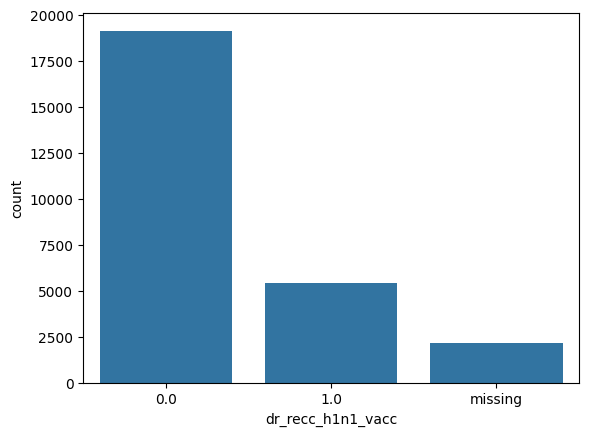

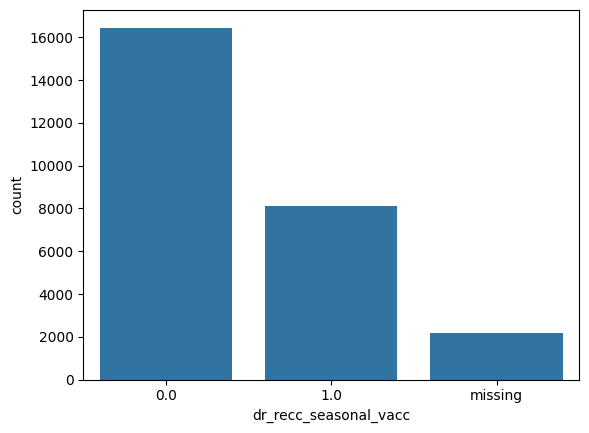

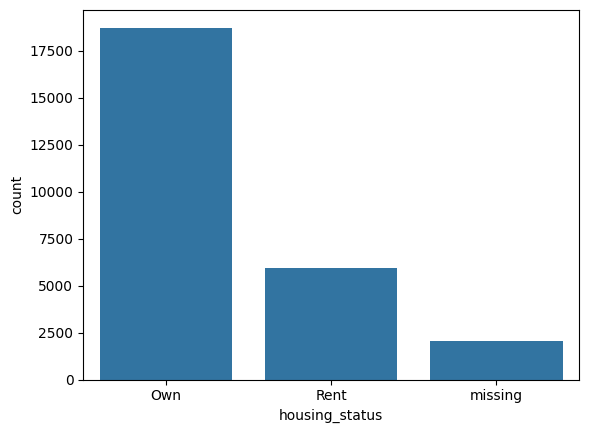

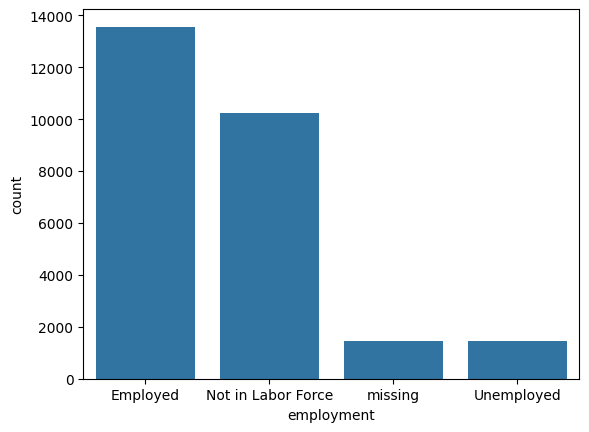

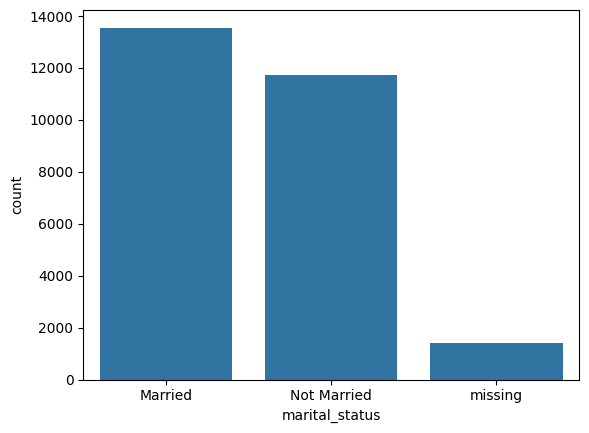

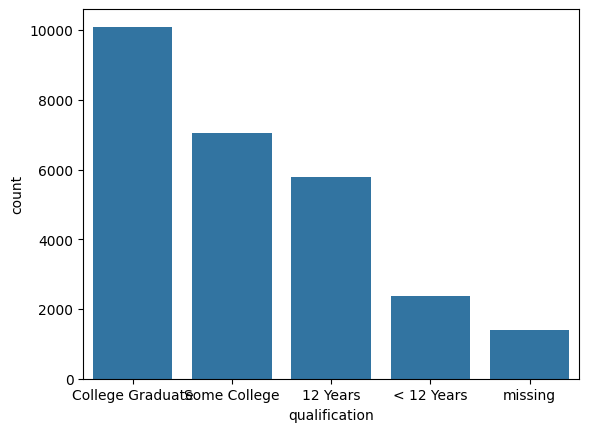

In [ ]:
# plot count plot for each column in moderate_missing_cols to determine.
# wether missing_values are overpowered by mode.
for col in moderate_missing_cols:
  temp = df[col].fillna("missing").value_counts()
  sns.barplot(temp)
  plt.show()

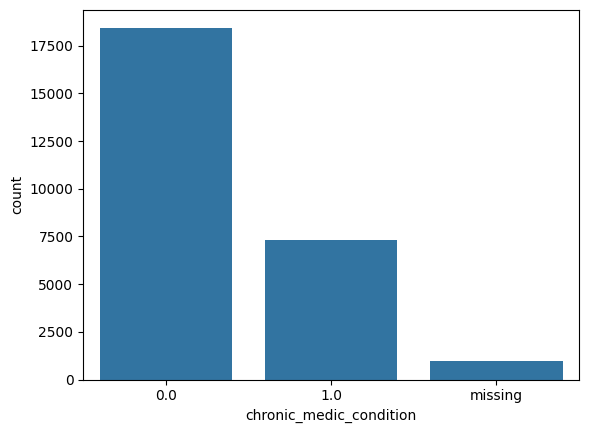

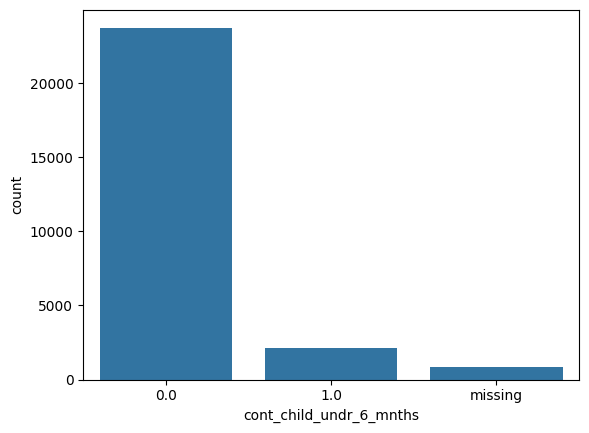

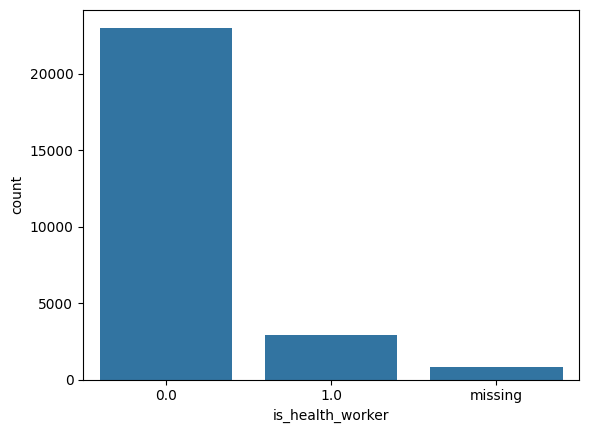

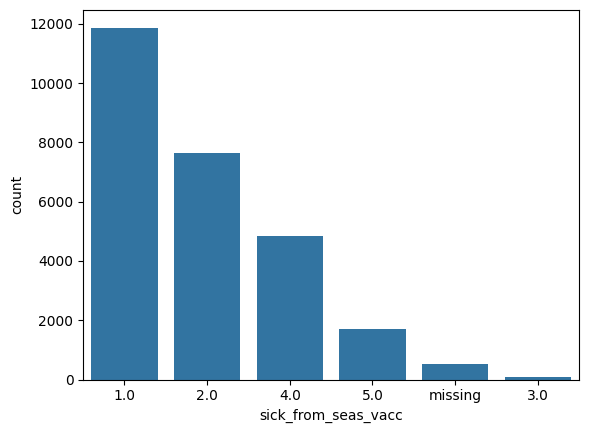

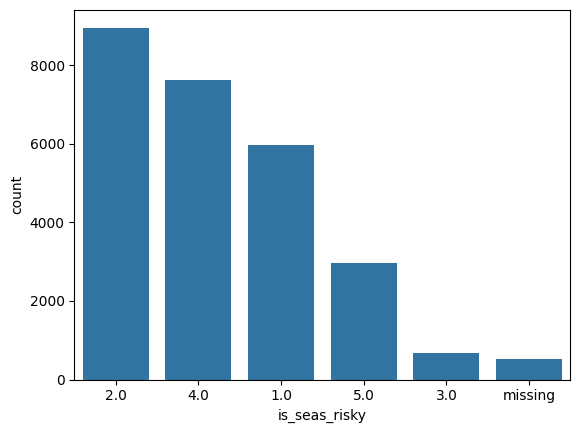

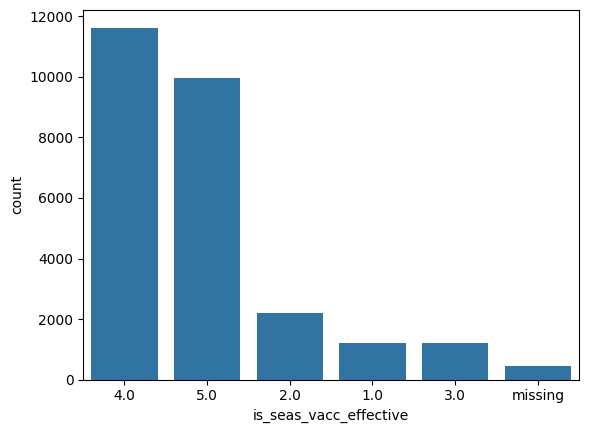

In [ ]:
for col in low_missing_cols:
  temp = df[col].fillna("missing").value_counts()
  sns.barplot(temp)
  plt.show()

missing strategy
has_health_insur --> impute with 0 and add missing_indicator
income_level --> mode with missing_indicator
moderate_missing_cols --> mode with missing_indicator
rest cols --> mode with missing_indicator

In [ ]:
## find ordinal or nominal data.
# find categorical cols.
cat_cols = df.select_dtypes(include= "object").columns
# display there unique values.
for col in cat_cols:
  print(col)
  print(df[col].unique())
  print("-----------------------------")





age_bracket
['55 - 64 Years' '35 - 44 Years' '18 - 34 Years' '65+ Years'
 '45 - 54 Years']
-----------------------------
qualification
['< 12 Years' '12 Years' 'College Graduate' 'Some College' nan]
-----------------------------
race
['White' 'Black' 'Other or Multiple' 'Hispanic']
-----------------------------
sex
['Female' 'Male']
-----------------------------
income_level
['Below Poverty' '<= $75,000, Above Poverty' '> $75,000' nan]
-----------------------------
marital_status
['Not Married' 'Married' nan]
-----------------------------
housing_status
['Own' 'Rent' nan]
-----------------------------
employment
['Not in Labor Force' 'Employed' 'Unemployed' nan]
-----------------------------
census_msa
['Non-MSA' 'MSA, Not Principle  City' 'MSA, Principle City']
-----------------------------


In [ ]:
nominal = ["census_msa", "employment", "housing_status", "marital_status" , "sex", "race" ]
ordinal = ["age_bracket" , "qualification" , "income_level"]


In [ ]:
moderate_missing_cols.values

array(['dr_recc_h1n1_vacc', 'dr_recc_seasonal_vacc', 'housing_status',
       'employment', 'marital_status', 'qualification'], dtype=object)

In [ ]:
low_missing_cols.values

array(['chronic_medic_condition', 'cont_child_undr_6_mnths',
       'is_health_worker', 'sick_from_seas_vacc', 'is_seas_risky',
       'is_seas_vacc_effective'], dtype=object)

In [ ]:
very_low_missing_cols.values

array(['sick_from_h1n1_vacc', 'is_h1n1_vacc_effective', 'is_h1n1_risky',
       'no_of_adults', 'no_of_children', 'contact_avoidance',
       'avoid_touch_face', 'h1n1_awareness', 'h1n1_worry',
       'avoid_large_gatherings', 'reduced_outside_home_cont',
       'antiviral_medication', 'wash_hands_frequently',
       'bought_face_mask'], dtype=object)